In [1]:
import numpy as np
from IQAEBinom import IQAEBinom
from IQAEBinom_OnlyFinalRound_EndCIReachTol import BiasFinalRound
import matplotlib.pyplot as plt
import pickle
import datetime
import pandas as pd

In [2]:
epsilon = 0.001
nEstim = 10000
alpha = 0.05
nShotUnit = 1

In [3]:
p = 0.2505
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230830_IQAEVariousP_nShotUnit1/results_IQAE_pTrue0.25049999999999994_epsilon0001_alpha005.dat", 'rb') as f:
    results = pickle.load(f)
errs = [r["Estimate"] - p for r in results]
print(np.mean(errs), np.std(errs))

3.6560845798100844e-05 0.0002866491428630229


In [11]:
np.std(errs) / np.sqrt(nEstim)

2.8664914286302288e-06

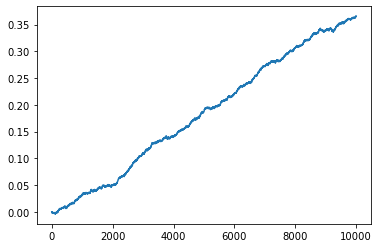

In [4]:
ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.show()

(array([  0.,   4., 121., 289., 572., 568., 392., 365., 340., 192., 184.,
        195., 236., 397., 557., 436., 732., 915., 620., 593., 513., 380.,
        328., 284., 199.,  76.,  65.,  28.,  63.,  31.,  25.,  26.,  24.,
         14.,   6.,  12.,   3.,   6.,   6.,   7.,   9.,   6.,   9.,   5.,
          6.,  11.,  32.,   0.,   6.,  16.,  26.,   1.,   9.,  15.,   8.,
         10.,  13.,  14.,   0.,   0.]),
 array([100., 110., 120., 130., 140., 150., 160., 170., 180., 190., 200.,
        210., 220., 230., 240., 250., 260., 270., 280., 290., 300., 310.,
        320., 330., 340., 350., 360., 370., 380., 390., 400., 410., 420.,
        430., 440., 450., 460., 470., 480., 490., 500., 510., 520., 530.,
        540., 550., 560., 570., 580., 590., 600., 610., 620., 630., 640.,
        650., 660., 670., 680., 690., 700.]),
 <BarContainer object of 60 artists>)

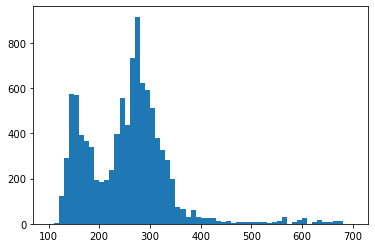

In [5]:
plt.hist([r["nGrover"][-1] for r in results], range=(100,700), bins=60)

In [6]:
nGUniq = np.unique([r["nGrover"][-1] for r in results])

In [7]:
termBiases = []
for nG in nGUniq:
    termBiases.append(BiasFinalRound(p, nG, epsilon, alpha, nShotUnit, nEstim, minRatio=2))

biasDf = pd.DataFrame({"nGrover":nGUniq, "Bias":termBiases})

In [8]:
errsBiasCorrec = np.zeros(nEstim)

for i in range(len(results)):
    errsBiasCorrec[i] = errs[i] - biasDf[biasDf["nGrover"]==results[i]["nGrover"][-1]]["Bias"]

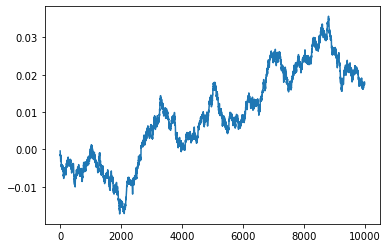

In [9]:
ax = plt.gca()
plt.plot(np.array(errsBiasCorrec).cumsum())
plt.show()

In [15]:
# 全10000試行に対してbias計算するのは無理そう... とりあえず2000試行
errsBiasCorrec_realistic = np.zeros(2000)
biasesReal = []

#for i in range(len(results)):
for i in range(2000):
    if i % 10 == 0:
        print(i, datetime.datetime.now())
    r = results[i]
    biasReal = BiasFinalRound(r["Estimate"], r["nGrover"][-1], epsilon, alpha, nShotUnit, nEstim, minRatio=2)
    errsBiasCorrec_realistic[i] = errs[i] - biasReal
    biasesReal.append(biasReal)

0 2023-09-05 15:43:40.497374
10 2023-09-05 15:47:10.293020
20 2023-09-05 15:48:43.145048
30 2023-09-05 15:51:25.457303
40 2023-09-05 15:52:38.377219


c:\Users\koich\Desktop\Code\QAEErrorVsNShotNGrover\IQAEBinom_OnlyFinalRound_EndCIReachTol.py:69: RuntimeWarning: Mean of empty slice
  return np.nanmean(errs)


50 2023-09-05 15:53:47.635284
60 2023-09-05 15:56:10.644449
70 2023-09-05 15:58:43.931496
80 2023-09-05 15:59:34.772585
90 2023-09-05 16:00:12.667235
100 2023-09-05 16:02:16.205885
110 2023-09-05 16:02:50.636169
120 2023-09-05 16:04:28.292668
130 2023-09-05 16:05:16.465011
140 2023-09-05 16:05:51.218259
150 2023-09-05 16:06:51.874052
160 2023-09-05 16:07:18.819814
170 2023-09-05 16:10:14.020238
180 2023-09-05 16:11:05.082181
190 2023-09-05 16:11:51.992072
200 2023-09-05 16:12:39.598783
210 2023-09-05 16:13:33.831771
220 2023-09-05 16:17:38.270217
230 2023-09-05 16:23:06.125899
240 2023-09-05 16:23:38.017078
250 2023-09-05 16:25:53.197344
260 2023-09-05 16:26:36.227971
270 2023-09-05 16:27:34.896029
280 2023-09-05 16:29:07.830434
290 2023-09-05 16:30:46.866390
300 2023-09-05 16:31:32.150594
310 2023-09-05 16:36:32.674648
320 2023-09-05 16:39:54.877347
330 2023-09-05 16:41:50.447499
340 2023-09-05 16:43:56.517709
350 2023-09-05 16:44:45.459126
360 2023-09-05 16:45:36.974925
370 2023-09-0

In [16]:
np.savetxt('C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/termBias_p0.2505_epsilon0001_alpha005_nShotUnit1.csv', biasesReal)

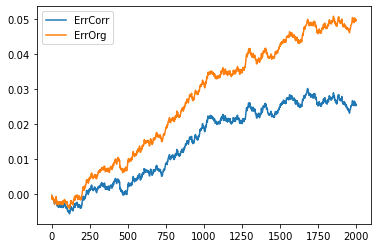

In [33]:
ax = plt.gca()
plt.plot(np.nancumsum(errsBiasCorrec_realistic), label="ErrCorr")
plt.plot(np.nancumsum(errs)[:2000], label="ErrOrg")
plt.legend()
plt.show()